# RACE Project — Exploratory Data Analysis
**Course:** Artificial Intelligence — BS(CS) Spring 2026  
**Dataset:** RACE (ReAding Comprehension from Examinations)  
**Source file:** `train.csv` only  
**Split strategy:** 80% train / 20% validation (stratified on answer label)  

---
### What this notebook covers
1. Setup & Data Loading  
2. Basic Sanity Checks  
3. Missing Value Handling  
4. Answer Label Distribution  
5. Text Length Analysis  
6. Question Type Analysis  
7. Vocabulary & Word Frequency  
8. Answer–Article Overlap  
9. Distractor Analysis  
10. TF-IDF Preview  
11. 80-20 Train/Val Split  
12. Summary Statistics Table

## Section 1 — Setup & Imports

In [1]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split
from pathlib import Path

warnings.filterwarnings('ignore')
np.random.seed(42)

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

(ROOT / "data" / "raw").mkdir(parents=True, exist_ok=True)
(ROOT / "data" / "processed").mkdir(parents=True, exist_ok=True)
(ROOT / "eda_plots").mkdir(parents=True, exist_ok=True)

RAW_TRAIN = ROOT / "data" / "raw" / "train.csv"
PROC_DIR = ROOT / "data" / "processed"
EDA_PLOTS = ROOT / "eda_plots"

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})

print('Setup complete.')
print(f'ROOT={ROOT}')
print(f'RAW_TRAIN={RAW_TRAIN}')



Setup complete.
ROOT=/home/talha-shafi/FAST/AI/proj/race_rc_project
RAW_TRAIN=/home/talha-shafi/FAST/AI/proj/race_rc_project/data/raw/train.csv


## Section 2 — Load train.csv

In [2]:
df = pd.read_csv(RAW_TRAIN)

df = df.drop(columns=['Unnamed: 0'], errors='ignore')

print(f'Shape: {df.shape}')
print(f'Columns : {df.columns.tolist()}')
print(f'Expected cols : [id, article, question, A, B, C, D, answer]')
print(f'\nData types:')
print(df.dtypes)
print(f'\nFirst 5 rows:')
df.head(5)



Shape: (87866, 8)
Columns : ['id', 'article', 'question', 'A', 'B', 'C', 'D', 'answer']
Expected cols : [id, article, question, A, B, C, D, answer]

Data types:
id          str
article     str
question    str
A           str
B           str
C           str
D           str
answer      str
dtype: object

First 5 rows:


,id,article,question,A,B,C,D,answer
0,middle7348.txt,In the summer between my first year and second...,Before the writer came to the high school summ...,instructor,camper,student,reporter,C
1,middle7348.txt,In the summer between my first year and second...,How many times did the writer invite the boy t...,Once,Twice,Three times,Many times,B
2,middle4305.txt,A bumpkin went to a big city for the first t...,The bumpkin thought _ .,his wife was as beautiful as the young girl,his wife was more beautiful than the short fat...,the short fat woman changed to a young girl in...,He should also buy a room of that kind for his...,C
3,middle4305.txt,A bumpkin went to a big city for the first t...,The room he saw was perhaps _ .,an office,a toilet,a lift,a helicopter,C
4,middle4305.txt,A bumpkin went to a big city for the first t...,We can see that the bumpkin had no knowledge ...,farming or gardening,how to do farm work,how to live in a city,modern city life,D


## Section 3 — Missing Values & Duplicates

In [3]:

print('=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(4)
missing_report = pd.DataFrame({'Missing Count': missing, 'Percentage %': missing_pct})
print(missing_report)

dupes = df.duplicated().sum()
print(f'\nDuplicate rows: {dupes}')

#Dropping null rows
# Impact: ~14 rows out of ~87,866 = 0.016% — negligible
rows_before = len(df)
df = df.dropna(subset=['A', 'B', 'C', 'D'])
df = df.reset_index(drop=True)
rows_after  = len(df)

print(f'\nRows before cleaning : {rows_before:,}')
print(f'Rows dropped: {rows_before - rows_after}')
print(f'Rows after cleaning: {rows_after:,}')
print(f'Data retained: {rows_after/rows_before*100:.3f}%')

assert df.isnull().sum().sum() == 0, 'Still has nulls!'
print('\nVerification passed — zero nulls remaining.')

=== Missing Values ===
          Missing Count  Percentage %
id                    0        0.0000
article               0        0.0000
question              0        0.0000
A                     4        0.0046
B                     0        0.0000
C                     1        0.0011
D                     9        0.0102
answer                0        0.0000

Duplicate rows: 1

Rows before cleaning : 87,866
Rows dropped: 14
Rows after cleaning: 87,852
Data retained: 99.984%

Verification passed — zero nulls remaining.


## Section 4 — Answer Label Distribution

Answer Label Distribution:
        Count  Percentage %
answer                     
A       19142         21.79
B       22722         25.86
C       23887         27.19
D       22101         25.16

Baseline accuracy approx 25.00%
Most common label : C at 27.19%


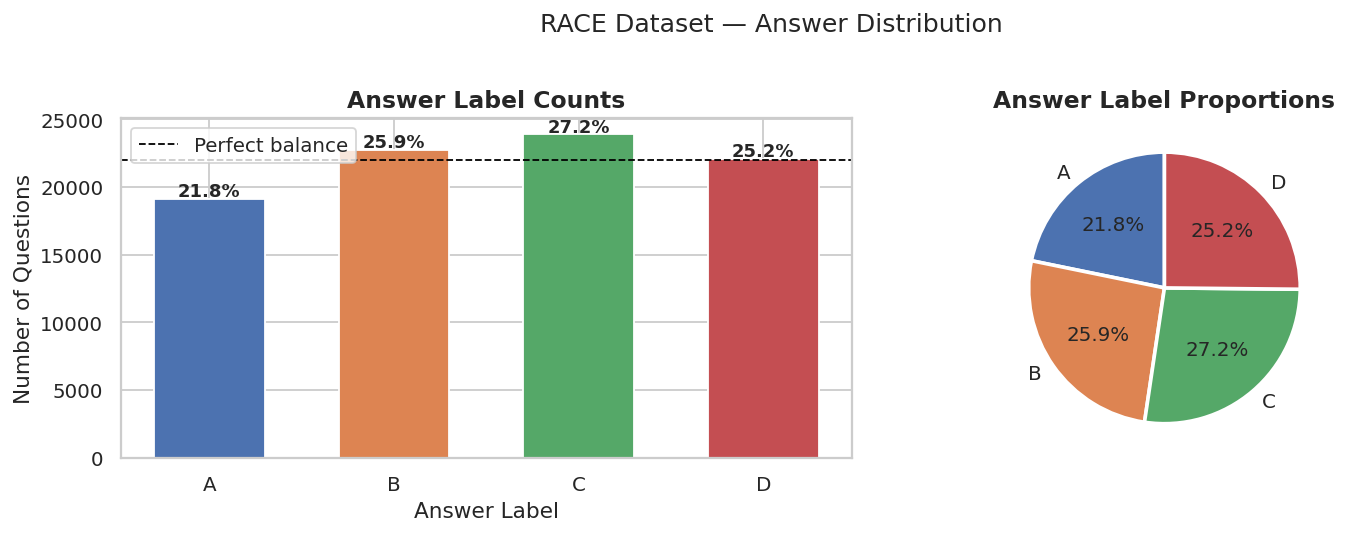


Insight: Distribution is roughly uniform (~25% each).
=> No class weighting needed


In [4]:
# ── Count and proportions ─────────────────────────────────────────────────────
answer_counts = df['answer'].value_counts().sort_index()
answer_pcts = df['answer'].value_counts(normalize=True).sort_index() * 100

print('Answer Label Distribution:')
report = pd.DataFrame({'Count': answer_counts, 'Percentage %': answer_pcts.round(2)})
print(report)
print(f'\nBaseline accuracy approx 25.00%')
print(f"Most common label : {answer_pcts.idxmax()} at {answer_pcts.max():.2f}%")

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

# Bar chart
bars = axes[0].bar(answer_counts.index, answer_counts.values, color=colors, edgecolor='white', width=0.6)
axes[0].set_title('Answer Label Counts', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Answer Label')
axes[0].set_ylabel('Number of Questions')
axes[0].axhline(len(df)/4, color='black', linestyle='--', linewidth=1, label='Perfect balance')
axes[0].legend()
for bar, pct in zip(bars, answer_pcts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{pct:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Pie chart
axes[1].pie(answer_counts.values, labels=answer_counts.index,
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Answer Label Proportions', fontsize=13, fontweight='bold')

plt.suptitle('RACE Dataset — Answer Distribution', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(str(EDA_PLOTS / '01_answer_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\nInsight: Distribution is roughly uniform (~25% each).')
print('=> No class weighting needed')

## Section 5 — Text Length Analysis

In [5]:
# Word Count
for col in ['article', 'question', 'A', 'B', 'C', 'D']:
    df[f'{col}_len'] = df[col].str.split().str.len()

len_cols = ['article_len', 'question_len', 'A_len', 'B_len', 'C_len', 'D_len']

#Summary stats
print('Word Count Statistics:')
print(df[len_cols].describe().round(1))

# Percentile table 
percentiles = [50, 75, 90, 95, 99]
print('\nKey Percentiles for Article Length')
for p in percentiles:
    val = np.percentile(df['article_len'], p)
    print(f'  {p}th percentile: {val:.0f} words')

Word Count Statistics:
       article_len  question_len    A_len    B_len    C_len    D_len
count      87852.0       87852.0  87852.0  87852.0  87852.0  87852.0
mean         275.0          10.0      5.4      5.6      5.8      5.9
std           97.9           3.4      3.3      3.4      3.5      3.6
min            2.0           1.0      1.0      1.0      1.0      1.0
25%          217.0           8.0      3.0      3.0      3.0      3.0
50%          279.0          10.0      5.0      5.0      6.0      6.0
75%          326.0          12.0      8.0      8.0      8.0      8.0
max         1162.0          63.0     91.0    105.0     48.0     67.0

Key Percentiles for Article Length
  50th percentile: 279 words
  75th percentile: 326 words
  90th percentile: 373 words
  95th percentile: 413 words
  99th percentile: 610 words


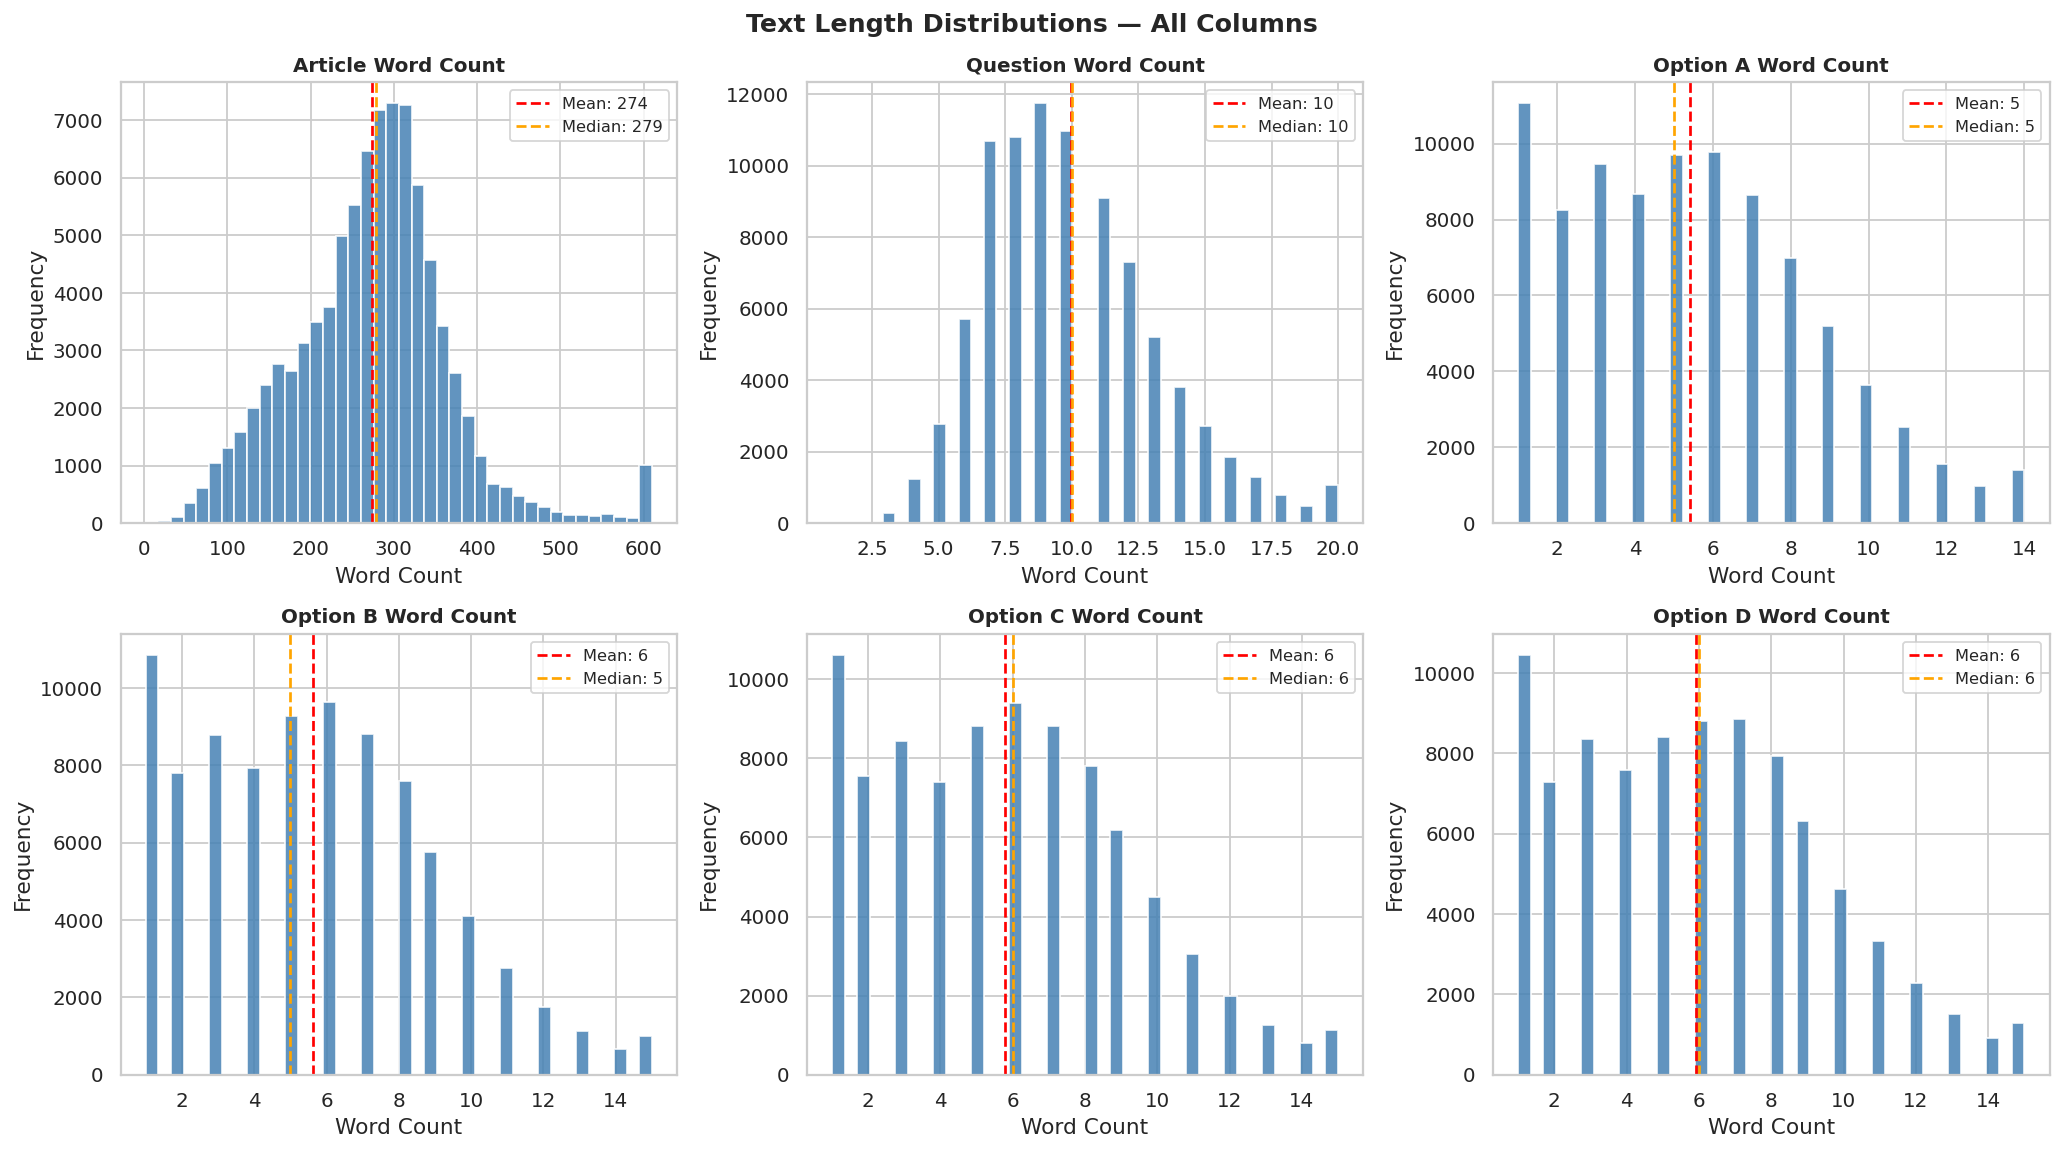

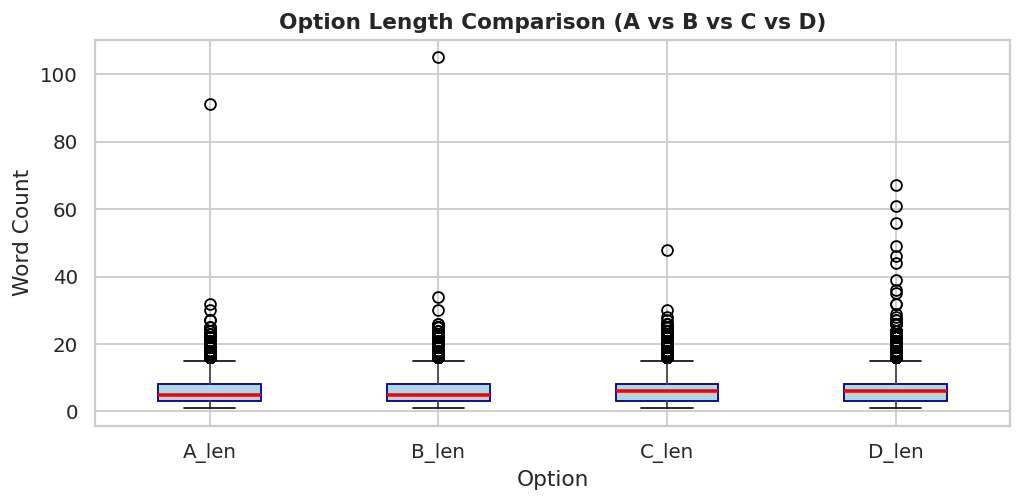

If option lengths vary widely, the correct answer can be exploited by the model

Correct answer avg length : 5.9 words
All options avg length : 5.7 words
Gap : 0.2 words

No length bias detected — safe to proceed.


In [6]:
# Plot distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

labels = {
    'article_len' : 'Article Word Count',
    'question_len': 'Question Word Count',
    'A_len'       : 'Option A Word Count',
    'B_len'       : 'Option B Word Count',
    'C_len'       : 'Option C Word Count',
    'D_len'       : 'Option D Word Count',
}

for ax, (col, title) in zip(axes, labels.items()):
    data = df[col].clip(upper=df[col].quantile(0.99))
    ax.hist(data, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(),   color='red',    linestyle='--', linewidth=1.5,
               label=f'Mean: {data.mean():.0f}')
    ax.axvline(data.median(), color='orange', linestyle='--', linewidth=1.5,
               label=f'Median: {data.median():.0f}')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Word Count')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)

plt.suptitle('Text Length Distributions — All Columns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(EDA_PLOTS / '02_length_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Box plot comparing option lengths ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
option_lens = df[['A_len','B_len','C_len','D_len']]
option_lens.boxplot(ax=ax, patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='navy'),
                    medianprops=dict(color='red', linewidth=2))
ax.set_title('Option Length Comparison (A vs B vs C vs D)', fontweight='bold')
ax.set_ylabel('Word Count')
ax.set_xlabel('Option')
plt.tight_layout()
plt.savefig(str(EDA_PLOTS / '02b_option_length_boxplot.png'), dpi=150, bbox_inches='tight')
plt.show()

print('If option lengths vary widely, the correct answer can be exploited by the model')
correct_avg = df.apply(lambda r: r[f'{r.answer}_len'], axis=1).mean()
all_avg= df[['A_len', 'B_len', 'C_len', 'D_len']].values.mean()
gap = correct_avg - all_avg

print(f'\nCorrect answer avg length : {correct_avg:.1f} words')
print(f'All options avg length : {all_avg:.1f} words')
print(f'Gap : {gap:.1f} words')

if abs(gap) < 0.5:
    print(f'\nNo length bias detected — safe to proceed.')
elif abs(gap) < 1.5:
    print(f'\nMinor bias detected — monitor per-class F1 during training.')
else:
    print(f'\nWARNING: Serious length bias detected — model may exploit answer length.')

## Section 6 — Question Type Analysis

Question Type Distribution:
  Fill-in-blank  : 43,426  (49.4%)
  What           : 16,894  (19.2%)
  Which          : 10,828  (12.3%)
  Other          :  4,557  (5.2%)
  Why            :  4,114  (4.7%)
  How            :  3,447  (3.9%)
  When           :  2,249  (2.6%)
  Who            :  1,234  (1.4%)
  Where          :  1,103  (1.3%)


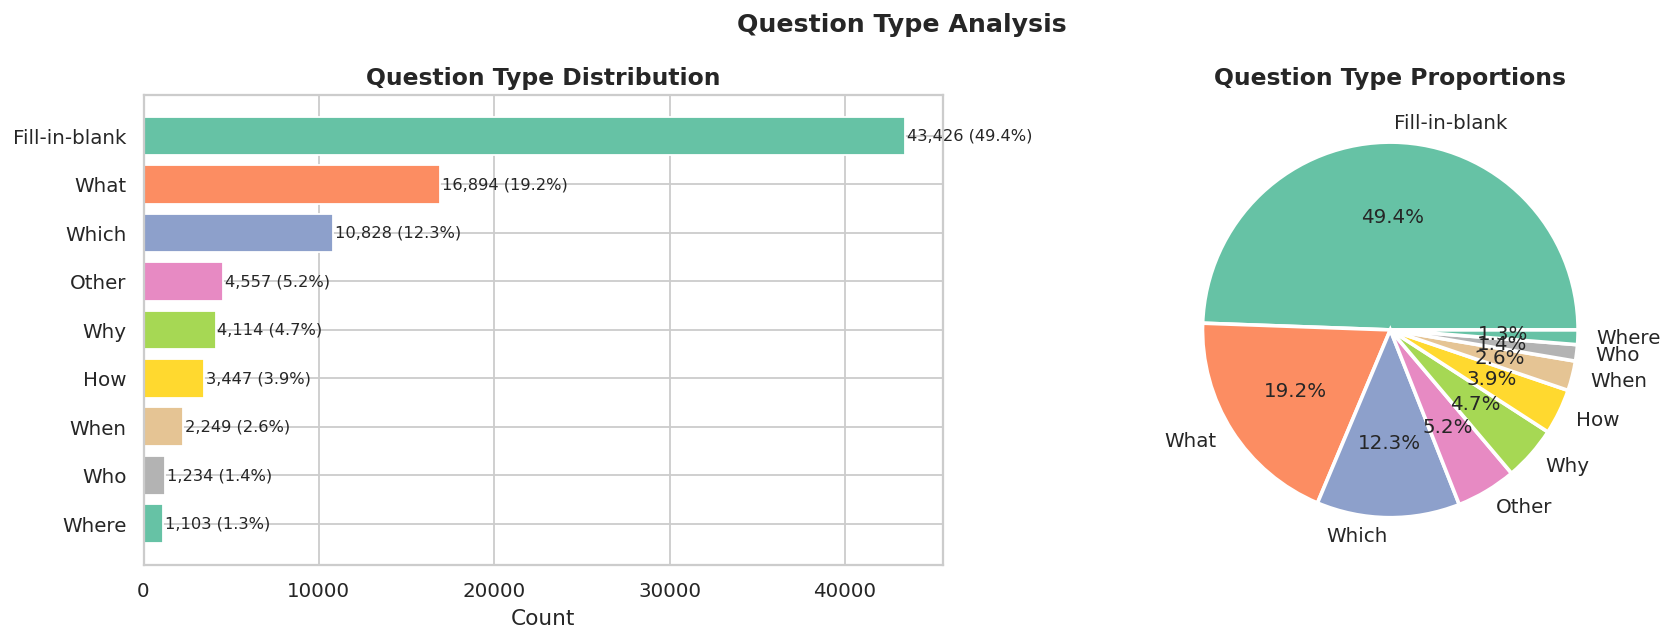


Insight for Model A:
  Fill-in-blank questions: 49.4% — these need different template handling
  Other/non-Wh questions : 5.2% — Wh-word templates wont apply to these


In [7]:
#Classify questions
def get_question_type(question):
    q = str(question).lower().strip()
    for wh in ['what', 'who', 'where', 'when', 'why', 'how', 'which']:
        if q.startswith(wh):
            return wh.capitalize()
    # Fill-in-the-blank: contains underscore or 'blank'
    if '_' in q or 'blank' in q:
        return 'Fill-in-blank'
    return 'Other'

df['question_type'] = df['question'].apply(get_question_type)

type_counts = df['question_type'].value_counts()
print('Question Type Distribution:')
for qtype, count in type_counts.items():
    print(f'  {qtype:15s}: {count:6,}  ({count/len(df)*100:.1f}%)')

# Plot 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette = sns.color_palette('Set2', len(type_counts))

# Horizontal bar chart
axes[0].barh(type_counts.index[::-1], type_counts.values[::-1],
             color=palette[::-1], edgecolor='white')
axes[0].set_title('Question Type Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Count')
for i, (idx, val) in enumerate(zip(type_counts.index[::-1], type_counts.values[::-1])):
    axes[0].text(val + 100, i, f'{val:,} ({val/len(df)*100:.1f}%)', va='center', fontsize=9)

# Pie chart
axes[1].pie(type_counts.values, labels=type_counts.index,
            autopct='%1.1f%%', colors=palette,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Question Type Proportions', fontsize=13, fontweight='bold')

plt.suptitle('Question Type Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(EDA_PLOTS / '03_question_types.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\nInsight for Model A:')
fill_pct = type_counts.get('Fill-in-blank', 0) / len(df) * 100
other_pct = type_counts.get('Other', 0) / len(df) * 100
print(f'  Fill-in-blank questions: {fill_pct:.1f}% — these need different template handling')
print(f'  Other/non-Wh questions : {other_pct:.1f}% — Wh-word templates wont apply to these')

Answer Balance by Question Type (%):
answer            A     B     C     D
question_type                        
Fill-in-blank  22.0  26.1  27.0  24.9
How            19.3  28.6  29.7  22.4
Other          21.6  25.3  27.3  25.7
What           23.0  25.6  26.7  24.6
When           22.2  25.9  27.6  24.3
Where          23.1  27.1  28.0  21.8
Which          20.8  25.1  26.9  27.2
Who            22.8  24.5  28.8  24.0
Why            18.8  25.2  28.3  27.7


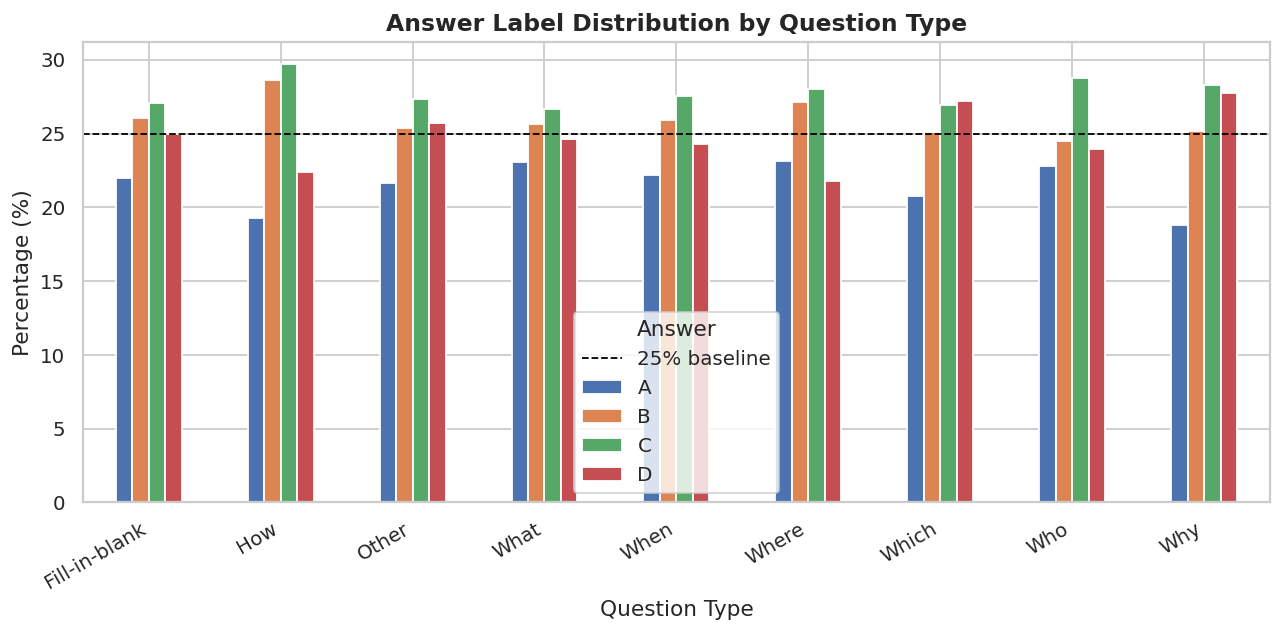

In [8]:

cross = pd.crosstab(df['question_type'], df['answer'], normalize='index') * 100
print('Answer Balance by Question Type (%):')
print(cross.round(1))

fig, ax = plt.subplots(figsize=(10, 5))
cross.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.set_title('Answer Label Distribution by Question Type', fontsize=13, fontweight='bold')
ax.set_ylabel('Percentage (%)')
ax.set_xlabel('Question Type')
ax.axhline(25, color='black', linestyle='--', linewidth=1, label='25% baseline')
ax.legend(title='Answer')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(str(EDA_PLOTS / '03b_answer_by_qtype.png'), dpi=150, bbox_inches='tight')
plt.show()

## Section 7 — Vocabulary & Word Frequency

In [9]:
def tokenize(text):
    return re.findall(r'\b[a-z]{2,}\b', str(text).lower())

# Build vocabulary from articles
print('Building vocabulary from articles (may take ~1 min)...')
all_words = []
for article in df['article']:
    all_words.extend(tokenize(article))

word_freq = Counter(all_words)
print(f'Total tokens        : {len(all_words):,}')
print(f'Unique vocabulary   : {len(word_freq):,}')
print(f'Avg tokens/article  : {len(all_words)/len(df):.0f}')

# ── Top 20 words WITH stopwords ───────────────────────────────────────────────
print(f'\nTop 20 words (with stopwords):')
for word, count in word_freq.most_common(20):
    print(f'  {word:15s}: {count:>8,}')

# ── After stopword removal ────────────────────────────────────────────────────
content_words = [w for w in all_words if w not in ENGLISH_STOP_WORDS]
content_freq  = Counter(content_words)

print(f'\nContent words (after stopword removal): {len(content_words):,}')
print(f'Unique content vocabulary             : {len(content_freq):,}')

# ── Words appearing only once ─────────────────────────────────────────────────
rare_words = sum(1 for c in word_freq.values() if c == 1)
print(f'Words appearing only once             : {rare_words:,}')
print(f'  => These are typos/rare proper nouns — setting min_df=2 removes all of them')

Building vocabulary from articles (may take ~1 min)...
Total tokens        : 23,272,612
Unique vocabulary   : 65,538
Avg tokens/article  : 265

Top 20 words (with stopwords):
  the            : 1,278,028
  to             :  730,804
  and            :  634,920
  of             :  538,442
  in             :  459,366
  is             :  289,633
  that           :  259,159
  it             :  253,558
  you            :  242,160
  for            :  229,051
  was            :  179,967
  are            :  177,987
  he             :  177,554
  on             :  162,842
  they           :  161,100
  with           :  151,128
  have           :  133,138
  at             :  131,821
  as             :  130,467
  be             :  127,622

Content words (after stopword removal): 11,288,180
Unique content vocabulary             : 65,234
Words appearing only once             : 688
  => These are typos/rare proper nouns — setting min_df=2 removes all of them


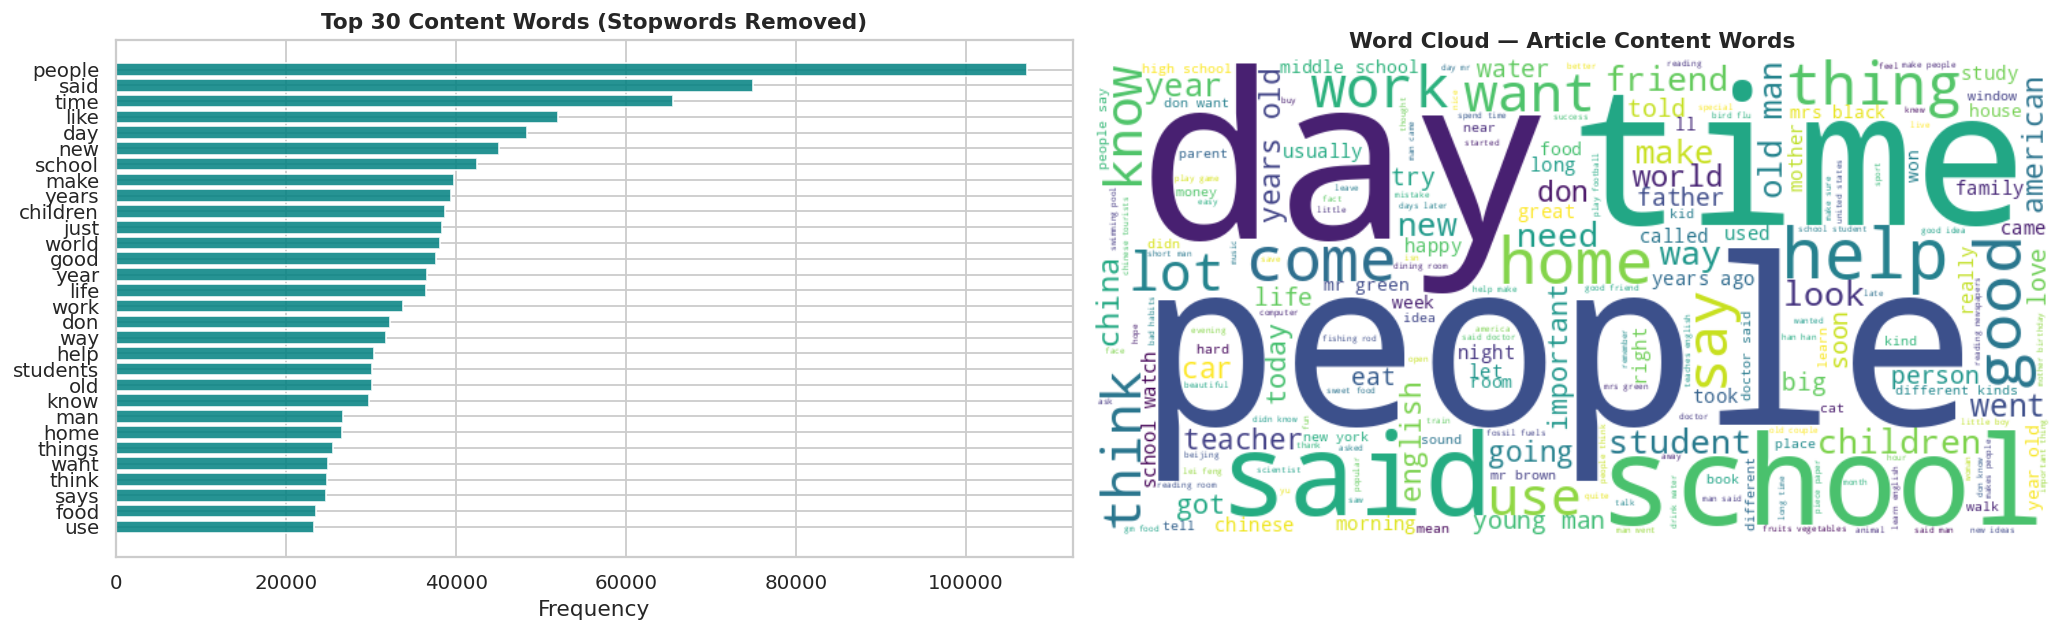

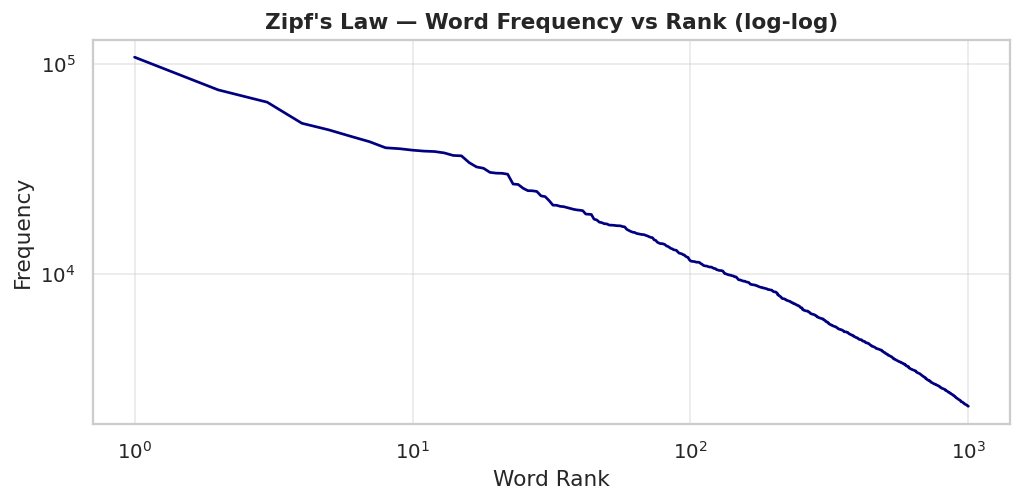


Insight for Preprocessing:
  Rare words (freq=1)    : 688  — set min_df=2 in TfidfVectorizer
  Top 5,000 words cover  : 86.6% of all content word tokens
  Top 10,000 words cover : 93.7% of all content word tokens
  => max_features=10000 in TfidfVectorizer is well justified


In [10]:
# Plots
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top 30 content words bar chart
top30 = content_freq.most_common(30)
words30, counts30 = zip(*top30)
axes[0].barh(list(words30)[::-1], list(counts30)[::-1],
             color='teal', edgecolor='white', alpha=0.85)
axes[0].set_title('Top 30 Content Words (Stopwords Removed)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Frequency')

# Word cloud
wc_text = ' '.join(content_words[:100000])
wc = WordCloud(width=700, height=350, background_color='white',
               max_words=200, colormap='viridis',
               prefer_horizontal=0.8).generate(wc_text)
axes[1].imshow(wc, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Word Cloud — Article Content Words', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(str(EDA_PLOTS / '04_word_frequency.png'), dpi=150, bbox_inches='tight')
plt.show()

# Zipf's law plot
fig, ax = plt.subplots(figsize=(8, 4))
top_n = 1000
top_counts = [c for _, c in content_freq.most_common(top_n)]
ax.loglog(range(1, top_n+1), top_counts, color='navy', linewidth=1.5)
ax.set_title("Zipf's Law — Word Frequency vs Rank (log-log)", fontweight='bold')
ax.set_xlabel('Word Rank')
ax.set_ylabel('Frequency')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(str(EDA_PLOTS / '04b_zipf.png'), dpi=150, bbox_inches='tight')
plt.show()

# Preprocessing insights 
print('\nInsight for Preprocessing:')
print(f'  Rare words (freq=1)    : {rare_words:,}  — set min_df=2 in TfidfVectorizer')
top5k_coverage  = sum(c for _, c in content_freq.most_common(5000))  / len(content_words) * 100
top10k_coverage = sum(c for _, c in content_freq.most_common(10000)) / len(content_words) * 100
print(f'  Top 5,000 words cover  : {top5k_coverage:.1f}% of all content word tokens')
print(f'  Top 10,000 words cover : {top10k_coverage:.1f}% of all content word tokens')
print(f'  => max_features=10000 in TfidfVectorizer is well justified')

## Section 8 — Answer–Article Overlap Analysis

In [11]:
def word_overlap_ratio(text_a, text_b):

    words_a = set(tokenize(str(text_a)))
    words_b = set(tokenize(str(text_b)))
    if not words_b:
        return 0.0
    return len(words_a & words_b) / len(words_b)


print('Computing answer-article overlap (sample of 10,000 rows for speed)...')
sample = df.sample(10000, random_state=42).copy()

sample['answer_text']   = sample.apply(lambda r: str(r[r['answer']]), axis=1)
sample['ans_art_overlap'] = sample.apply(
    lambda r: word_overlap_ratio(r['article'], r['answer_text']), axis=1)
sample['q_art_overlap']   = sample.apply(
    lambda r: word_overlap_ratio(r['article'], r['question']), axis=1)

print(f"Correct answer overlap with article:")
print(f"  Mean   : {sample['ans_art_overlap'].mean():.3f}")
print(f"  Median : {sample['ans_art_overlap'].median():.3f}")
print(f"  Questions with >0% overlap  : {(sample['ans_art_overlap'] > 0).mean()*100:.1f}%")
print(f"  Questions with >50% overlap : {(sample['ans_art_overlap'] > 0.5).mean()*100:.1f}%")
print(f"  Questions with 0% overlap   : {(sample['ans_art_overlap'] == 0).mean()*100:.1f}% (pure reasoning required)")

Computing answer-article overlap (sample of 10,000 rows for speed)...
Correct answer overlap with article:
  Mean   : 0.670
  Median : 0.714
  Questions with >0% overlap  : 90.1%
  Questions with >50% overlap : 71.4%
  Questions with 0% overlap   : 9.9% (pure reasoning required)


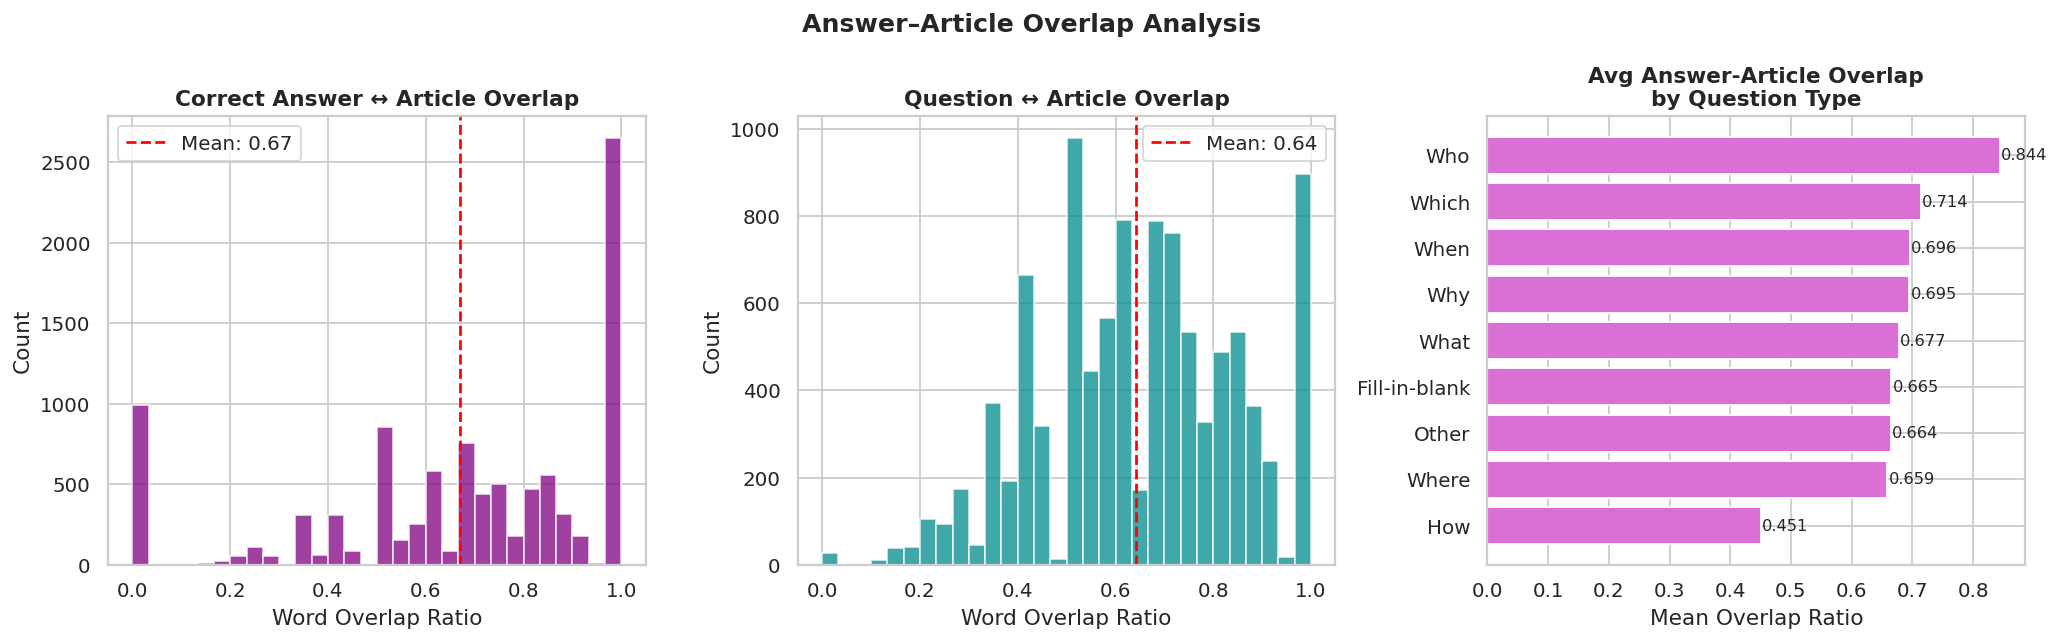


Insight for Model A:
  Mean overlap   : 0.670
  90.1% of correct answers have at least some word overlap with the article.
  9.9% require pure reasoning — TF-IDF will struggle on these.
  Overall: HIGH overlap dataset — TF-IDF cosine similarity is a strong feature.
  Expected model accuracy ceiling for classical ML: ~65-75%


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))


axes[0].hist(sample['ans_art_overlap'], bins=30, color='purple', alpha=0.75, edgecolor='white')
axes[0].axvline(sample['ans_art_overlap'].mean(), color='red', linestyle='--',
                label=f"Mean: {sample['ans_art_overlap'].mean():.2f}")
axes[0].set_title('Correct Answer ↔ Article Overlap', fontweight='bold')
axes[0].set_xlabel('Word Overlap Ratio')
axes[0].set_ylabel('Count')
axes[0].legend()

# Question-article overlap histogram
axes[1].hist(sample['q_art_overlap'], bins=30, color='darkcyan', alpha=0.75, edgecolor='white')
axes[1].axvline(sample['q_art_overlap'].mean(), color='red', linestyle='--',
                label=f"Mean: {sample['q_art_overlap'].mean():.2f}")
axes[1].set_title('Question ↔ Article Overlap', fontweight='bold')
axes[1].set_xlabel('Word Overlap Ratio')
axes[1].set_ylabel('Count')
axes[1].legend()

# Overlap by question type
type_overlap = sample.groupby('question_type')['ans_art_overlap'].mean().sort_values()
axes[2].barh(type_overlap.index, type_overlap.values, color='orchid', edgecolor='white')
axes[2].set_title('Avg Answer-Article Overlap\nby Question Type', fontweight='bold')
axes[2].set_xlabel('Mean Overlap Ratio')
for i, v in enumerate(type_overlap.values):
    axes[2].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)

plt.suptitle('Answer–Article Overlap Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(EDA_PLOTS / '05_answer_overlap.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\nInsight for Model A:')
print(f"  Mean overlap   : {sample['ans_art_overlap'].mean():.3f}")
print(f"  {(sample['ans_art_overlap'] > 0).mean()*100:.1f}% of correct answers have"
      f" at least some word overlap with the article.")
print(f"  {(sample['ans_art_overlap'] == 0).mean()*100:.1f}% require pure reasoning"
      f" — TF-IDF will struggle on these.")
print(f"  Overall: HIGH overlap dataset — TF-IDF cosine similarity is a strong feature.")
print(f"  Expected model accuracy ceiling for classical ML: ~65-75%")

## Section 9 — Distractor Analysis (for Model B)

In [13]:
def jaccard(text_a, text_b):
   
    a = set(tokenize(str(text_a)))
    b = set(tokenize(str(text_b)))
    if not a or not b:
        return 0.0
    return len(a & b) / len(a | b)


print('Computing distractor similarity on 5,000 samples...')
dist_sample = df.sample(5000, random_state=42).copy()

def avg_distractor_similarity(row):
    correct = row['answer']
    correct_text = str(row[correct])
    sims = []
    for opt in ['A','B','C','D']:
        if opt == correct:
            continue
        sims.append(jaccard(correct_text, str(row[opt])))
    return np.mean(sims)

def max_distractor_similarity(row):
    correct = row['answer']
    correct_text = str(row[correct])
    sims = []
    for opt in ['A','B','C','D']:
        if opt == correct:
            continue
        sims.append(jaccard(correct_text, str(row[opt])))
    return max(sims)

dist_sample['avg_dist_sim'] = dist_sample.apply(avg_distractor_similarity, axis=1)
dist_sample['max_dist_sim'] = dist_sample.apply(max_distractor_similarity, axis=1)

print(f"Average distractor-to-answer Jaccard similarity:")
print(f"  Mean   : {dist_sample['avg_dist_sim'].mean():.4f}")
print(f"  Median : {dist_sample['avg_dist_sim'].median():.4f}")
print(f"  Max    : {dist_sample['avg_dist_sim'].max():.4f}")
print(f"\nFraction with avg_sim > 0.1 (somewhat similar): {(dist_sample['avg_dist_sim'] > 0.1).mean()*100:.1f}%")
print(f"Fraction with avg_sim == 0  (no word overlap) : {(dist_sample['avg_dist_sim'] == 0).mean()*100:.1f}%")

Computing distractor similarity on 5,000 samples...
Average distractor-to-answer Jaccard similarity:
  Mean   : 0.1303
  Median : 0.1007
  Max    : 1.0000

Fraction with avg_sim > 0.1 (somewhat similar): 50.4%
Fraction with avg_sim == 0  (no word overlap) : 24.9%


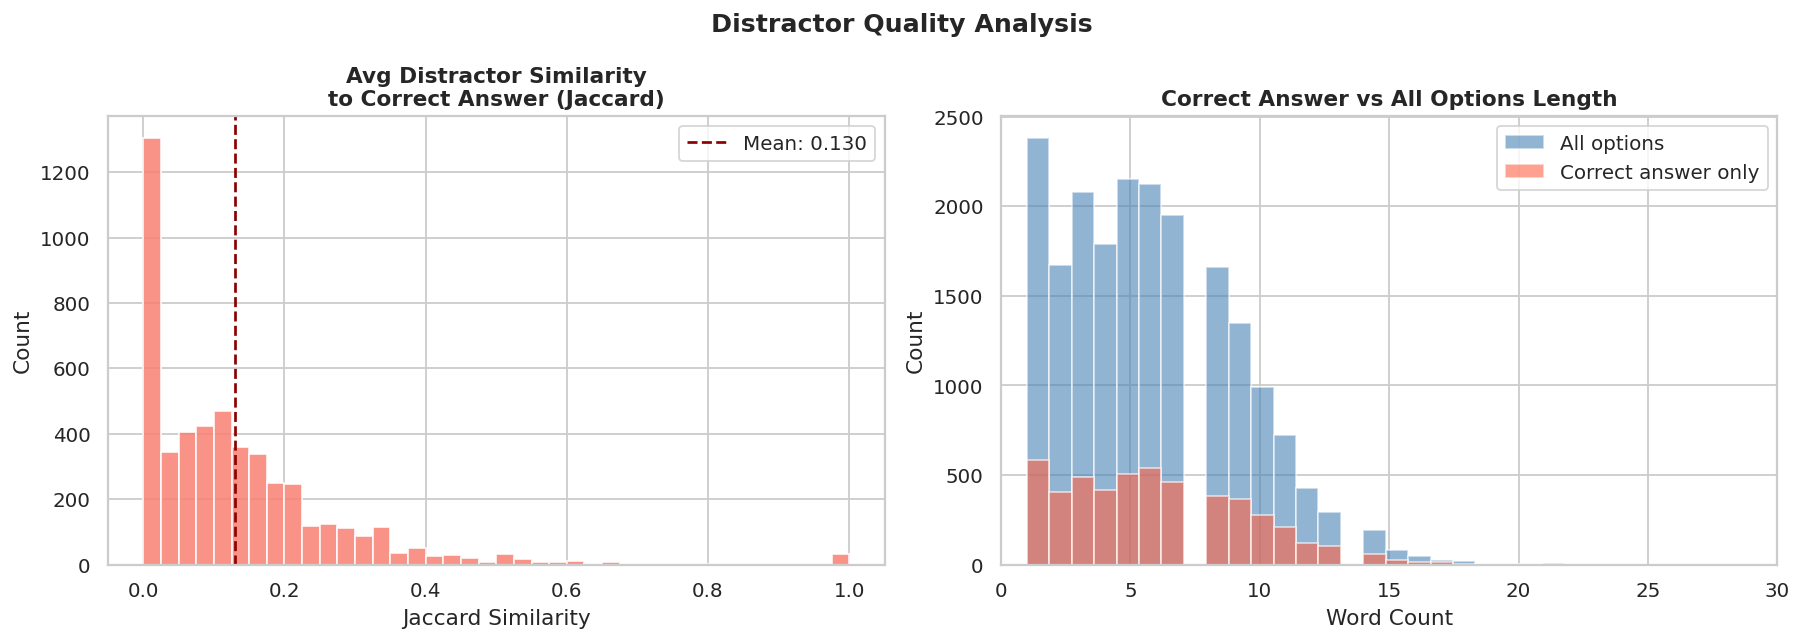


Insight for Model B (Distractor Generator):
  Distractors have LOW similarity to correct answer (mean Jaccard ~ 0.130).
  => Good distractors are semantically RELATED but lexically DIFFERENT.
  => Cosine similarity on TF-IDF (not Jaccard) is a better selection criterion.
  Correct answer length (6.0) is similar to all options (5.7) — no length bias.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(dist_sample['avg_dist_sim'], bins=40, color='salmon', edgecolor='white', alpha=0.85)
axes[0].axvline(dist_sample['avg_dist_sim'].mean(), color='darkred', linestyle='--',
                label=f"Mean: {dist_sample['avg_dist_sim'].mean():.3f}")
axes[0].set_title('Avg Distractor Similarity\nto Correct Answer (Jaccard)', fontweight='bold')
axes[0].set_xlabel('Jaccard Similarity')
axes[0].set_ylabel('Count')
axes[0].legend()

# Option length distribution — check if correct answer is systematically longer
correct_lens  = dist_sample.apply(lambda r: len(str(r[r['answer']]).split()), axis=1)
all_opt_lens  = dist_sample[['A_len','B_len','C_len','D_len']].values.flatten()
axes[1].hist(all_opt_lens,      bins=30, alpha=0.6, color='steelblue', label='All options', edgecolor='white')
axes[1].hist(correct_lens,      bins=30, alpha=0.6, color='tomato',    label='Correct answer only', edgecolor='white')
axes[1].set_title('Correct Answer vs All Options Length', fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].set_xlim(0, 30)

plt.suptitle('Distractor Quality Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(EDA_PLOTS / '06_distractor_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\nInsight for Model B (Distractor Generator):')
print(f"  Distractors have LOW similarity to correct answer (mean Jaccard ~ {dist_sample['avg_dist_sim'].mean():.3f}).")
print('  => Good distractors are semantically RELATED but lexically DIFFERENT.')
print('  => Cosine similarity on TF-IDF (not Jaccard) is a better selection criterion.')
avg_correct_len = correct_lens.mean()
avg_all_len     = all_opt_lens.mean()
if abs(avg_correct_len - avg_all_len) > 0.5:
    print(f'  WARNING: Correct answers avg {avg_correct_len:.1f} words vs all options {avg_all_len:.1f} — length bias detected!')
else:
    print(f'  Correct answer length ({avg_correct_len:.1f}) is similar to all options ({avg_all_len:.1f}) — no length bias.')

## Section 10 — TF-IDF Preview

In [15]:
print('Fitting TF-IDF on 5,000 article sample to preview vocabulary...')

sample_articles = df['article'].sample(5000, random_state=42).tolist()

vectorizer = TfidfVectorizer(
    max_features = 10000,
    stop_words   = 'english',
    sublinear_tf = True,
    ngram_range  = (1, 2),
    min_df       = 2,
    max_df       = 0.95,
)

X_sample = vectorizer.fit_transform(sample_articles)
feature_names = vectorizer.get_feature_names_out()

print(f'TF-IDF matrix shape : {X_sample.shape}')
print(f'Sparsity            : {1 - X_sample.nnz/(X_sample.shape[0]*X_sample.shape[1]):.2%} zeros')
print(f'Vocabulary size     : {len(feature_names):,}')

# ── Top terms by average TF-IDF ───────────────────────────────────────────────
mean_tfidf = np.asarray(X_sample.mean(axis=0)).flatten()
top_idx    = mean_tfidf.argsort()[-20:][::-1]

print('\nTop 20 terms by average TF-IDF score:')
tfidf_top = pd.DataFrame({
    'Term'       : feature_names[top_idx],
    'Avg TF-IDF' : mean_tfidf[top_idx].round(5)
})
print(tfidf_top.to_string(index=False))

Fitting TF-IDF on 5,000 article sample to preview vocabulary...
TF-IDF matrix shape : (5000, 10000)
Sparsity            : 99.05% zeros
Vocabulary size     : 10,000

Top 20 terms by average TF-IDF score:
    Term  Avg TF-IDF
  people     0.02381
    said     0.01991
    time     0.01883
    like     0.01765
     day     0.01694
  school     0.01510
    good     0.01509
     new     0.01500
   years     0.01456
    make     0.01447
    just     0.01409
   world     0.01369
    work     0.01345
    life     0.01342
    year     0.01324
     don     0.01322
    know     0.01290
children     0.01289
     way     0.01273
     old     0.01250


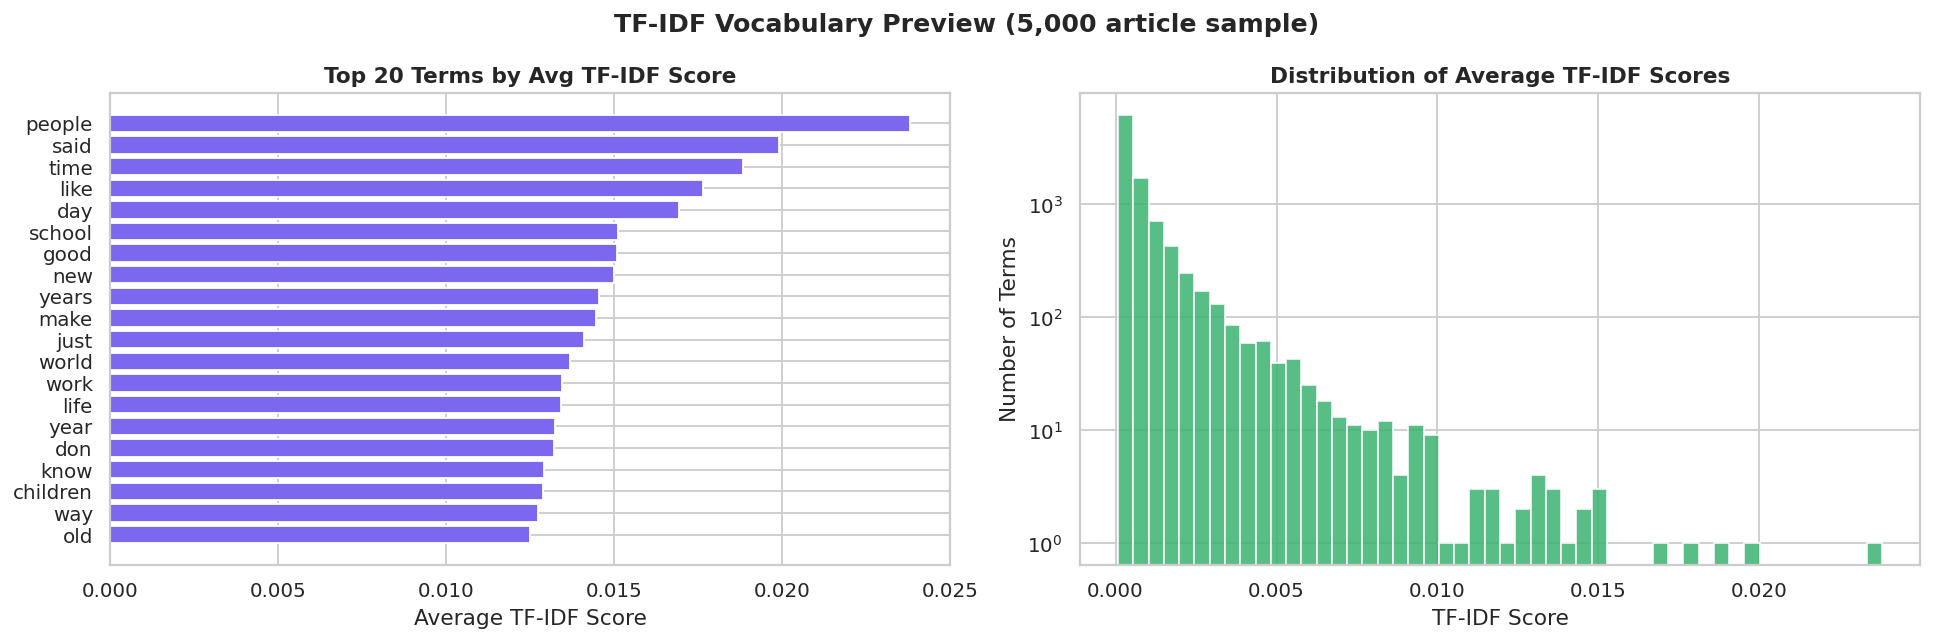


Top 8 TF-IDF terms for article index 0:
  alice                          0.4503
  bobby                          0.3689
  tony                           0.2903
  grandparents                   0.2625
  black                          0.1964
  big family                     0.1895
  girl                           0.1823
  cousins                        0.1811


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Top 20 terms bar chart
axes[0].barh(tfidf_top['Term'][::-1], tfidf_top['Avg TF-IDF'][::-1],
             color='mediumslateblue', edgecolor='white')
axes[0].set_title('Top 20 Terms by Avg TF-IDF Score', fontweight='bold')
axes[0].set_xlabel('Average TF-IDF Score')

# TF-IDF score distribution
axes[1].hist(mean_tfidf[mean_tfidf > 0], bins=50, color='mediumseagreen',
             edgecolor='white', alpha=0.85)
axes[1].set_title('Distribution of Average TF-IDF Scores', fontweight='bold')
axes[1].set_xlabel('TF-IDF Score')
axes[1].set_ylabel('Number of Terms')
axes[1].set_yscale('log')

plt.suptitle('TF-IDF Vocabulary Preview (5,000 article sample)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(EDA_PLOTS / '07_tfidf_preview.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Article-level top terms example ──────────────────────────────────────────
print('\nTop 8 TF-IDF terms for article index 0:')
import scipy.sparse as sp_module
doc_vec = X_sample[0]
nz = doc_vec.nonzero()[1]
doc_scores = [(feature_names[i], doc_vec[0, i]) for i in nz]
doc_scores.sort(key=lambda x: x[1], reverse=True)
for term, score in doc_scores[:8]:
    print(f'  {term:30s} {score:.4f}')

## Section 11 — 80/20 Train / Validation Split
Since we only have `train.csv`, we split it ourselves. Stratified on `answer` to keep label balance equal in both halves.

In [17]:
from sklearn.model_selection import train_test_split

train_split, val_split = train_test_split(
    df,
    test_size    = 0.20,        # 20% validation
    random_state = 42,          # reproducible
    stratify     = df['answer'] # keep A/B/C/D proportions equal in both splits
)

train_split = train_split.reset_index(drop=True)
val_split   = val_split.reset_index(drop=True)

print('=== Split Summary ===')
print(f'Full dataset : {len(df):,} rows')
print(f'Train split  : {len(train_split):,} rows  ({len(train_split)/len(df)*100:.1f}%)')
print(f'Val split    : {len(val_split):,} rows  ({len(val_split)/len(df)*100:.1f}%)')

# ── Verify stratification worked ──────────────────────────────────────────────
print('\n=== Answer Balance Verification ===')
balance_check = pd.DataFrame({
    'Full Dataset (%)' : df['answer'].value_counts(normalize=True).sort_index() * 100,
    'Train Split (%)'  : train_split['answer'].value_counts(normalize=True).sort_index() * 100,
    'Val Split (%)'    : val_split['answer'].value_counts(normalize=True).sort_index() * 100,
}).round(2)
print(balance_check)
print('\nIf Train Split % ≈ Val Split % → stratification worked correctly ✅')

=== Split Summary ===
Full dataset : 87,852 rows
Train split  : 70,281 rows  (80.0%)
Val split    : 17,571 rows  (20.0%)

=== Answer Balance Verification ===
        Full Dataset (%)  Train Split (%)  Val Split (%)
answer                                                  
A                  21.79            21.79          21.79
B                  25.86            25.86          25.87
C                  27.19            27.19          27.19
D                  25.16            25.16          25.16

If Train Split % ≈ Val Split % → stratification worked correctly ✅


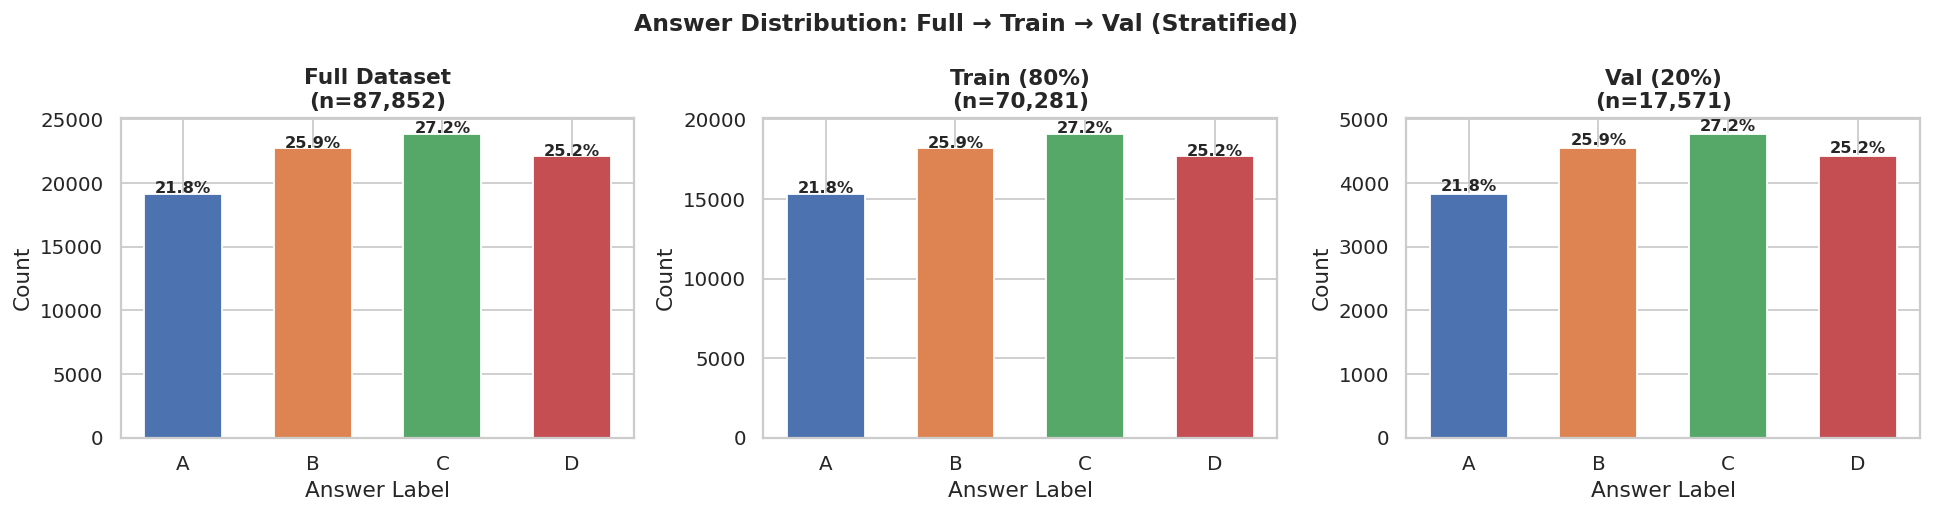


Splits saved to:
  data/processed/train_split.csv
  data/processed/val_split.csv

Your friend should load THESE files for model training, not the original train.csv.


In [18]:
# ── Visualise the split ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

datasets   = [('Full Dataset', df), ('Train (80%)', train_split), ('Val (20%)', val_split)]
plot_colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for ax, (name, data) in zip(axes, datasets):
    counts = data['answer'].value_counts().sort_index()
    bars   = ax.bar(counts.index, counts.values, color=plot_colors, edgecolor='white', width=0.6)
    ax.set_title(f'{name}\n(n={len(data):,})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Answer Label')
    ax.set_ylabel('Count')
    total = counts.sum()
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{val/total*100:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Answer Distribution: Full → Train → Val (Stratified)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(EDA_PLOTS / '08_train_val_split.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Save the splits ───────────────────────────────────────────────────────────
train_split.to_csv(PROC_DIR / 'train_split.csv', index=False)
val_split.to_csv(PROC_DIR / 'val_split.csv', index=False)
print('\nSplits saved to:')
print('  data/processed/train_split.csv')
print('  data/processed/val_split.csv')
print('\nYour friend should load THESE files for model training, not the original train.csv.')

## Section 12 — Summary Statistics Table

In [19]:
summary = {
    'Metric': [
        '── DATASET ──',
        'Total rows (after cleaning)',
        'Rows dropped (missing options)',
        'Train split size (80%)',
        'Val split size (20%)',
        '',
        '── ARTICLES ──',
        'Avg article length (words)',
        'Median article length (words)',
        '95th percentile article length',
        '99th percentile article length',
        '',
        '── QUESTIONS ──',
        'Avg question length (words)',
        'Most common question type',
        'Fill-in-blank questions (%)',
        '',
        '── VOCABULARY ──',
        'Total tokens (articles)',
        'Unique vocabulary size',
        'Top 10k words coverage',
        '',
        '── ANSWER LABELS ──',
        'Most common label share',
        'Baseline accuracy (random)',
        '',
        '── OVERLAP ──',
        'Correct answer > 0% overlap with article',
        'Correct answer == 0% overlap (inference required)',
        '',
        '── PREPROCESSING RECOMMENDATIONS ──',
        'Recommended max_features (TF-IDF)',
        'Recommended min_df',
        'Recommended max_df',
        'Use sublinear_tf',
        'Use stop_words',
    ],
    'Value': [
        '',
        f"{rows_after:,}",
        f"{rows_before - rows_after}",
        f"{len(train_split):,}",
        f"{len(val_split):,}",
        '',
        '',
        f"{df['article_len'].mean():.0f}",
        f"{df['article_len'].median():.0f}",
        f"{np.percentile(df['article_len'], 95):.0f}",
        f"{np.percentile(df['article_len'], 99):.0f}",
        '',
        '',
        f"{df['question_len'].mean():.1f}",
        f"{df['question_type'].value_counts().index[0]}",
        f"{df['question_type'].value_counts(normalize=True).get('Fill-in-blank', 0)*100:.1f}%",
        '',
        '',
        f"{len(all_words):,}",
        f"{len(word_freq):,}",
        f"{top10k_coverage:.1f}%",
        '',
        '',
        f"{df['answer'].value_counts(normalize=True).max()*100:.2f}%",
        '25.00%',
        '',
        '',
        f"{(sample['ans_art_overlap'] > 0).mean()*100:.1f}%",
        f"{(sample['ans_art_overlap'] == 0).mean()*100:.1f}%",
        '',
        '',
        '10,000',
        '2',
        '0.95',
        'True',
        'english',
    ]
}

summary_df = pd.DataFrame(summary)
print('=== EDA SUMMARY TABLE ===')
print(summary_df.to_string(index=False))

summary_df.to_csv(PROC_DIR / 'eda_summary.csv', index=False)
print('\nSummary saved to data/processed/eda_summary.csv')

=== EDA SUMMARY TABLE ===
                                           Metric         Value
                                    ── DATASET ──              
                      Total rows (after cleaning)        87,852
                   Rows dropped (missing options)            14
                           Train split size (80%)        70,281
                             Val split size (20%)        17,571
                                                               
                                   ── ARTICLES ──              
                       Avg article length (words)           275
                    Median article length (words)           279
                   95th percentile article length           413
                   99th percentile article length           610
                                                               
                                  ── QUESTIONS ──              
                      Avg question length (words)          10.0
              

In [20]:
print('='*60)
print('  EDA COMPLETE')
print('='*60)
print()
print('Files produced:')
print('  data/processed/train_split.csv   <- 80% for model training')
print('  data/processed/val_split.csv     <- 20% for evaluation')
print('  data/processed/eda_summary.csv   <- summary table')
print('  eda_plots/                        <- all visualisation PNGs')
print()
print('Key findings for model trainer:')
print(f'  1. Answer labels are balanced (~25% each) — no class weighting needed')
print(f'  2. {(sample["ans_art_overlap"]==0).mean()*100:.0f}% questions require inference (not extraction)')
print(f'  3. Use max_features=10000 in TF-IDF — covers {top10k_coverage:.0f}% of content tokens')
print(f'  4. 95th pct article length = {np.percentile(df["article_len"],95):.0f} words — set truncation limit here')
print(f'  5. Stratified split confirmed — val set mirrors train distribution')

  EDA COMPLETE

Files produced:
  data/processed/train_split.csv   <- 80% for model training
  data/processed/val_split.csv     <- 20% for evaluation
  data/processed/eda_summary.csv   <- summary table
  eda_plots/                        <- all visualisation PNGs

Key findings for model trainer:
  1. Answer labels are balanced (~25% each) — no class weighting needed
  2. 10% questions require inference (not extraction)
  3. Use max_features=10000 in TF-IDF — covers 94% of content tokens
  4. 95th pct article length = 413 words — set truncation limit here
  5. Stratified split confirmed — val set mirrors train distribution
